(02-06-efficiente-markten)=

# Fama en de efficiënte markt

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1965–1970, met uitlopers naar 1978 en 1991.

**Wat we al weten.** In [](#01-02-bachelier) werd de random walk gemeten:
opeenvolgende koersveranderingen bleken vrijwel ongecorreleerd, en een kleine
afwijking was pas na decennia data te zien. In [](#02-05-crsp-tape) kreeg Chicago
de machine: een band met de maandrendementen van elk NYSE-aandeel sinds 1926. Daar
bleek ook dat de constructie van zo'n database de getallen verschuift. Wat nog
ontbrak, was een economisch argument waarom koersen onvoorspelbaar zouden
moeten zijn.

**Welke vraag staat open.** Wat betekent het dat een prijs *alle informatie
weerspiegelt*, en kunnen data die uitspraak weerleggen?
```

## Overzicht

Wat betekent het dat een prijs alle informatie weerspiegelt, en valt dat te
toetsen? Het betekent dat niemand met die informatie een hoger rendement kan
verwachten dan beleggers voor wachten en risico eisen. Omdat dat vereiste
rendement nergens vastligt, is efficiëntie alleen te toetsen samen met een model
ervan.

In deze lecture:

- rekenen we met de hand een markt door waarin de prijs onder risiconeutraliteit
  onvoorspelbaar is en onder risicoaversie niet, zonder dat iemand zich vergist;

- bewijzen we de stelling van Samuelson, en laten we zien dat elk patroon van
  voorspelbaarheid een rationele verklaring heeft;

- delen we de toetsen in naar de drie vormen van Fama: zwak, semi-sterk en sterk;

- simuleren we een rationele economie waarin een onderzoeker met het verkeerde
  model toch inefficiëntie vindt;

- repliceren we de filterregels van Fama en Blume en, kort, de fondsalpha's van
  Jensen.

In 1965 verscheen het proefschrift van Eugene Fama in zijn geheel in het
januarinummer van de *Journal of Business*: tweeënzeventig pagina's over de dagrendementen van
de dertig Dow Jones-aandelen {cite}`Fama1965`. In hetzelfde voorjaar bewees Paul
Samuelson dat goed voorziene prijzen willekeurig bewegen {cite}`Samuelson1965`.
Fama leverde de metingen en het woord, Samuelson het bewijs dat
onvoorspelbaarheid een eigenschap is van goed gevormde verwachtingen, niet van de
natuur. In 1970 bracht Fama beide samen in een overzichtsartikel
{cite}`Fama1970`. Dat artikel sluit het tijdvak af dat in 1965 begon. Het maakte van de random
walk een hypothese over markten en informatie, met drie vormen die twintig jaar
empirisch werk indeelden.

Op de vraag theorie of feit (is dit een theorie die getoetst wordt, of een feit
dat op een verklaring wacht?) is het antwoord hier ongewoon. De
efficiënte-markthypothese is een theorie, maar ze verbiedt pas iets als er een
model van risico naast staat.

## Intuïtie: waarom zou dit waar zijn?

Fama beschreef een efficiënte markt eerst in woorden {cite}`Fama1965b`. Veel
rationele beleggers concurreren om de toekomstige waarde van aandelen te
voorspellen, en belangrijke informatie is voor iedereen bijna gratis. Ziet zo'n
belegger een voorspelbare winst, dan koopt hij tot die winst weg is. Wat daarna
nog aan prijsbeweging overblijft, komt door nieuws. Nieuws is wat nog niemand
wist, en dus is die beweging onvoorspelbaar.

Maar winst ten opzichte van wat? Niemand houdt een aandeel voor een verwacht
rendement van nul. Beleggers eisen een vergoeding voor wachten en voor risico, en
die vergoeding mag in de tijd bewegen. Stel dat beleggers in een recessie minder
risico kunnen dragen. Dan daalt de koers tot het verwachte rendement hoog genoeg
is om iemand het aandeel te laten houden.

Na een daling is het verwachte rendement dan hoger dan na een stijging. Dat is
voorspelbaarheid, en toch vergist niemand zich. Of een
patroon een inefficiëntie is, hangt dus af van het *vereiste* rendement: het
verwachte rendement dat het evenwicht voor het risico voorschrijft. Verwerpen de
data "efficiëntie plus mijn model van risico", dan weet niemand welk van de twee
faalt.

Er zit ook een paradox in het mechanisme. Als prijzen alle informatie perfect
weerspiegelen, verdient niemand iets aan het verzamelen ervan. Dan verzamelt
niemand haar, en kan de prijs haar ook niet weerspiegelen
{cite}`GrossmanStiglitz1980`.

We verwachten dus drie dingen, die de theorie hierna een voor een inlost:

1. Een prijs die de verwachting van een latere uitbetaling is, verandert
   onvoorspelbaar, ook als die uitbetaling zelf voorspelbaar is.

2. Met risicoaversie is het verwachte rendement wel voorspelbaar, en hoger na
   slecht nieuws, zonder dat iemand een fout maakt.

3. Als informatie geld kost, is een markt bruto nooit helemaal efficiënt, alleen
   na aftrek van kosten.

## Toy-voorbeeld: één aandeel, twee perioden, één stuk nieuws

Hetzelfde aandeel is een martingaal onder risiconeutraliteit en geen martingaal
onder risicoaversie. We laden eerst de pakketten voor de hele lecture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

**Opzet.** Er zijn drie tijdstippen, $t = 0, 1, 2$. Het aandeel betaalt alleen op
$t = 2$ een dividend $d_2$. Op $t = 1$ komt publiek nieuws, goed of slecht, elk
met kans $\tfrac12$. Het nieuws bepaalt welke twee dividenden daarna mogelijk
zijn, elk weer met kans $\tfrac12$. De rente is nul, dus het bruto risicovrije rendement is $R^f = 1$. Anders dan
in [](#00-00-setup) is $R^f$ in deze lecture bruto.

| nieuws op $t=1$ | $d_2$ als het meezit | $d_2$ als het tegenzit | $\E_1[d_2]$ |
|---|---|---|---|
| goed   | 140 | 100 | 120 |
| slecht | 100 |  60 |  80 |

**Het recept.** De prijs is de kansgewogen som van de payoffs, elk
vermenigvuldigd met een gewicht $m$ dat van de toestand afhangt:
$p_t = \E_t[m_{t+1} x_{t+1}]$. Dat gewicht is de *stochastic discount factor*
(SDF, stochastische disconteringsfactor: hoeveel een euro in die toestand waard
is). De payoff $x$ is $p_1$ op $t = 1$ en $d_2$ op $t = 2$.

**Stap 1, risiconeutraal ($m = 1$).** $p_1(\text{goed}) = 120$,
$p_1(\text{slecht}) = 80$ en $p_0 = \tfrac12 \cdot 120 + \tfrac12 \cdot 80 = 100$.
Dus $\E_0[p_1] = 100 = p_0$: de prijs is een martingaal, en elk verwacht rendement
is nul.

**Stap 2, risicoavers.** Nu is $m = 0{,}8$ in de gunstige uitkomst van elke
periode (goed nieuws op $t = 1$, meezitten op $t = 2$) en $m = 1{,}2$ in de
ongunstige. Een euro is meer waard als het tegenzit. Omdat
$\E[m] = 1$, blijft de rente nul. Achterwaarts rekenen:

$$
\begin{aligned}
p_1(\text{goed})   &= \tfrac12(0{,}8)(140) + \tfrac12(1{,}2)(100) = 56 + 60 = 116,\\
p_1(\text{slecht}) &= \tfrac12(0{,}8)(100) + \tfrac12(1{,}2)(60)  = 40 + 36 = 76,\\
p_0                &= \tfrac12(0{,}8)(116) + \tfrac12(1{,}2)(76)  = 46{,}4 + 45{,}6 = 92.
\end{aligned}
$$

**Stap 3, verwachte rendementen.** $\E_0[p_1] = \tfrac12(116 + 76) = 96 \neq 92$.
Het verwachte rendement over de eerste periode is $96/92 - 1 = 4{,}35\%$. Na goed
nieuws is het $120/116 - 1 = 3{,}45\%$, na slecht nieuws $80/76 - 1 = 5{,}26\%$.

**Vooruitblik.** Met gewichten $q = \tfrac12 \cdot 0{,}8 = 0{,}4$ en
$1 - q = 0{,}6$ in plaats van $\tfrac12$ is $0{,}4 \cdot 116 + 0{,}6 \cdot 76 = 92 = p_0$;
de theorie noemt die gewichten de *risiconeutrale kansen*.

Het verwachte rendement is dus hoger na een koersdaling. Een onderzoeker die een
constant verwacht rendement aanneemt, ziet een patroon: koop na een daling. Toch
vergist niemand zich. De risicocorrectie is na goed en na slecht nieuws gelijk,
$120 - 116 = 80 - 76 = 4$. Alleen is 4 op een prijs van 76 relatief meer dan op
116. De code rekent beide economieën door.

In [2]:
prob = 0.5
dividends = {"goed": (140.0, 100.0), "slecht": (100.0, 60.0)}  # (meezitten, tegenzitten)


def price(payoff_up, payoff_down, m=(1.0, 1.0)):
    """One-period price p = E[m x] with two equally likely states."""
    return prob * m[0] * payoff_up + prob * m[1] * payoff_down


def toy_economy(m):
    """Prices and expected returns in the two-period toy economy for SDF values m."""
    p1 = {news: price(*dividends[news], m=m) for news in dividends}
    p0 = price(p1["goed"], p1["slecht"], m=m)
    expected_p1 = prob * (p1["goed"] + p1["slecht"])
    q_up = prob * m[0] / (prob * m[0] + prob * m[1])       # risk-neutral probability
    return {
        "prijs op t=1, goed nieuws": p1["goed"],
        "prijs op t=1, slecht nieuws": p1["slecht"],
        "prijs op t=0": p0,
        "verwachte prijs op t=1": expected_p1,
        "verwacht rendement t=0 naar 1": expected_p1 / p0 - 1,
        "verwacht rendement na goed nieuws": np.mean(dividends["goed"]) / p1["goed"] - 1,
        "verwacht rendement na slecht nieuws": np.mean(dividends["slecht"]) / p1["slecht"] - 1,
        "verwachte prijs op t=1 onder q": q_up * p1["goed"] + (1 - q_up) * p1["slecht"],
    }


hand = {
    "prijs op t=1, goed nieuws": 116,
    "prijs op t=1, slecht nieuws": 76,
    "prijs op t=0": 92,
    "verwachte prijs op t=1": 96,
    "verwacht rendement t=0 naar 1": 0.0435,
    "verwacht rendement na goed nieuws": 0.0345,
    "verwacht rendement na slecht nieuws": 0.0526,
    "verwachte prijs op t=1 onder q": 92,
}
pd.DataFrame({
    "risiconeutraal, code": toy_economy((1.0, 1.0)),
    "risicoavers, met de hand": hand,
    "risicoavers, code": toy_economy((0.8, 1.2)),
}).round(4)

,"risiconeutraal, code","risicoavers, met de hand","risicoavers, code"
"prijs op t=1, goed nieuws",120.0,116.0000,116.0000
"prijs op t=1, slecht nieuws",80.0,76.0000,76.0000
prijs op t=0,100.0,92.0000,92.0000
verwachte prijs op t=1,100.0,96.0000,96.0000
verwacht rendement t=0 naar 1,0.0,0.0435,0.0435
verwacht rendement na goed nieuws,0.0,0.0345,0.0345
verwacht rendement na slecht nieuws,0.0,0.0526,0.0526
verwachte prijs op t=1 onder q,100.0,92.0000,92.0000


De handberekening en de code geven dezelfde getallen, en in de risiconeutrale
kolom vallen alle martingaalvarianten samen. Wat we nu weten: of "de prijs is een
martingaal" waar is, hangt af van het model van risico dat erbij hoort. Dat is
de *joint hypothesis* (gezamenlijke hypothese: elke toets van efficiëntie is
tegelijk een toets van een model van het vereiste rendement) in het klein.

## Theorie

We leiden vijf dingen af. Eerst geven we drie woorden voor onvoorspelbaar een
scherpe betekenis. Dan volgt de kern, de stelling van Samuelson: een prijs die
een voorwaardelijke verwachting is, verandert onvoorspelbaar. Daarna laten we zien
wat dat voor aandelen betekent: onvoorspelbaarheid geldt pas na weging met de
SDF. Omdat die SDF vrij te kiezen is, past vervolgens elk patroon van
voorspelbaarheid bij een SDF. Ten slotte laten we zien hoe het getoetst wordt: de drie vormen van Fama, de filterregel en de kosten van
informatie.

### Opzet: drie woorden voor onvoorspelbaar

De vroege literatuur gebruikte drie woorden voor onvoorspelbaar door elkaar, en
ze betekenen niet hetzelfde {cite}`Fama1970`. Laat $\mathcal{F}_t$ de informatie
zijn die op $t$ publiek is, bijvoorbeeld alle koersen tot en met vandaag, en
$\E_t[\cdot] = \E[\cdot \mid \mathcal{F}_t]$. Fama schrijft $\Phi_t$ waar wij
$\mathcal{F}_t$ schrijven.

:::{prf:definition} Fair game, martingaal, random walk
:label: thm-efficiente-markten-begrippen

1. Een rij $z_{t+1}$ is een **fair game** als $\E_t[z_{t+1}] = 0$. Fama past dit
   toe op $z_{t+1} = R_{t+1} - \E_t[R_{t+1}]$, met $\E_t[R_{t+1}]$ het vereiste
   rendement volgens een evenwichtsmodel. Zonder dat model is de uitspraak een
   tautologie, met het model toetsbaar.
2. Een prijsreeks is een **martingaal** als $\E_t[p_{t+1}] = p_t$, en een
   **submartingaal** als $\E_t[p_{t+1}] \ge p_t$.
3. Log-rendementen $\ell_{t+1} = \log R_{t+1}$ volgen een **random walk** als ze
   onafhankelijk en identiek verdeeld zijn: $f(\ell_{t+1} \mid \mathcal{F}_t) = f(\ell_{t+1})$.
:::

*Waarom zou dit waar zijn?* De drie woorden zeggen steeds minder over wat een
handelaar met het verleden kan. Bij een random walk helpt het verleden hem
nergens bij, ook niet bij het voorspellen van de spreiding. Bij een fair game
helpt het hem alleen niet om de afwijking van het vereiste rendement te
voorspellen. Hoe zwakker de uitspraak, hoe meer van de werkelijkheid erin past.

:::{prf:proposition} Van sterk naar zwak
:label: thm-efficiente-markten-hierarchie

(i) Is $\ell_{t+1}$ i.i.d. met verwachting $\mu$, dan is $z_{t+1} = \ell_{t+1} - \mu$
een fair game. (ii) Elke fair game met eindige variantie is ongecorreleerd met
elke functie $g$ van $\mathcal{F}_t$; in het bijzonder zijn de autocorrelaties
nul. (iii) Het omgekeerde van (i) geldt niet.
:::

:::{prf:proof}
:class: dropdown

(i) Onafhankelijkheid geeft $\E_t[\ell_{t+1}] = \mu$. (ii) Met herhaalde
verwachtingen is $\E[z_{t+1} g] = \E\left[g\, \E_t[z_{t+1}]\right] = 0$ en
$\E[z_{t+1}] = 0$. Kies $g = z_{t+1-k}$ voor de autocorrelatie van orde $k$.
(iii) Neem $z_{t+1} = \sigma_t \varepsilon_{t+1}$ met $\varepsilon$ i.i.d.
standaardnormaal en $\sigma_t^2 = a_0 + a_1 z_t^2$ met $a_0, a_1 > 0$. Dan is
$\E_t[z_{t+1}] = 0$, maar $\Var_t(z_{t+1}) = \sigma_t^2$ hangt van $z_t$ af.
$\square$
:::

Het tegenvoorbeeld in (iii) is de werkelijkheid: volatiliteit clustert. De toetsen uit [](#01-02-bachelier),
autocorrelaties en variance ratios (de variantie over meerdere perioden gedeeld
door het aantal perioden maal de eenperiodevariantie), meten eerste en tweede momenten. Ze toetsen dus een gevolg van
de fair game, deel (ii): ongecorreleerdheid met de koersgeschiedenis. Onafhankelijkheid
toetsen ze niet. Fama
noemde onafhankelijkheid in 1970 dan ook overbodig voor de theorie
{cite}`Fama1970`.

### Het kernresultaat: de stelling van Samuelson

Een prijs die gelijk is aan de voorwaardelijke verwachting van een latere
uitbetaling, verandert onvoorspelbaar, wat het onderliggende proces ook doet.

*Waarom zou dit waar zijn?* Denk aan een handelaar in termijncontracten op tarwe.
De termijnprijs is de beste schatting die de markt vandaag heeft van de spotprijs
op de leverdatum. Verwacht hij dat die schatting morgen stijgt, dan koopt hij
vandaag, en stijgt de termijnprijs al vandaag. Alleen wat morgen nieuw is, kan de
schatting nog verplaatsen.

Samuelson formuleerde het voor een contract dat op $T$ de spotprijs $S_T$
uitbetaalt, bij een rente van nul en zonder risicopremie {cite}`Samuelson1965`.
Die aanname maakt de termijnprijs $F_t$ een verwachting onder de werkelijke
kansen. Het is de risiconeutrale kolom van het toy-voorbeeld, waar
$p_0 = \E_0[p_1] = 100$ was.

:::{prf:theorem} Samuelson (1965)
:label: thm-efficiente-markten-samuelson

Laat $S_T$ integreerbaar zijn en $F_t = \E_t[S_T]$ voor $t \le T$. Dan geldt,
*ongeacht* het proces dat $S$ genereert:

```{math}
:label: eq-efficiente-markten-samuelson
\E_t[F_{t+1}] = F_t,
\qquad
\Cov\!\left(F_{t+1} - F_t,\; g(\mathcal{F}_t)\right) = 0
\quad\text{voor elke } g .
```
:::

:::{prf:proof}
Omdat $\mathcal{F}_t \subseteq \mathcal{F}_{t+1}$ geeft de wet van herhaalde
verwachtingen $\E_t[F_{t+1}] = \E_t\!\left[\E_{t+1}[S_T]\right] = \E_t[S_T] = F_t$.
Het tweede deel volgt uit {prf:ref}`thm-efficiente-markten-hierarchie` (ii).
$\square$
:::

In woorden: de verwachte verandering van de termijnprijs is nul, en geen functie
van de informatie van vandaag voorspelt haar. Over de spotprijs is niets
aangenomen, en die mag voorspelbaar zijn. Neem een spotprijs die naar zijn gemiddelde
terugkeert, $S_{t+1} = \phi S_t + \nu_{t+1}$, met persistentie $\phi$
(hier 0,5) en een schok $\nu$ met variantie 1. Dan is
$F_t = \phi^{T-t} S_t$ en

```{math}
:label: eq-efficiente-markten-ar1
F_{t+1} - F_t = \phi^{T-t-1}\left(S_{t+1} - \phi S_t\right)
             = \phi^{T-t-1}\,\nu_{t+1} .
```

In woorden: de termijnprijs beweegt alleen met de schok van vandaag, niet met de
voorspelbare terugkeer van de spotprijs. Die spotprijsverandering heeft op $S_t$
een helling van $\phi - 1 = -0{,}5$. De cel simuleert 20 000 paden van twaalf
perioden en schat beide hellingen.

In [3]:
phi, horizon, n_paths = 0.5, 12, 20_000
spot = np.empty((n_paths, horizon + 1))
spot[:, 0] = rng.normal(0.0, 1.0 / np.sqrt(1 - phi**2), n_paths)  # stationary start
for t in range(1, horizon + 1):
    spot[:, t] = phi * spot[:, t - 1] + rng.normal(0.0, 1.0, n_paths)
futures = phi ** (horizon - np.arange(horizon + 1)) * spot       # F_t = E_t[S_T]


def pooled_slope(y, x):
    """Pooled OLS slope of y on x after demeaning both."""
    x, y = x.ravel() - x.mean(), y.ravel() - y.mean()
    return float(x @ y / (x @ x))


pd.DataFrame(
    {
        "helling op spotprijs (simulatie)": [
            pooled_slope(np.diff(spot, axis=1), spot[:, :-1]),
            pooled_slope(np.diff(futures, axis=1), spot[:, :-1]),
        ],
        "helling op spotprijs (theorie)": [phi - 1, 0.0],
    },
    index=["verandering spotprijs", "verandering termijnprijs"],
).round(3)

,helling op spotprijs (simulatie),helling op spotprijs (theorie)
verandering spotprijs,-0.500,-0.5
verandering termijnprijs,-0.001,0.0


De spotprijsverandering heeft de voorspelde helling van $-0{,}5$, de
termijnprijsverandering een helling van nul. Dat is de eerste verwachting uit de
intuïtie: de prijs is onvoorspelbaar, ook al is wat ze voorspelt dat niet. Wel
loopt de variantie van de termijnprijsverandering op naarmate de leverdatum nadert
(oefening 2).

### Wat het voorspelt: een martingaal na weging met de SDF

Voor aandelen geldt de stelling van Samuelson niet voor de prijs zelf, maar voor
de prijs na weging met de SDF.

*Waarom zou dit waar zijn?* Wie een aandeel koopt, legt vandaag geld neer en
draagt risico, en eist daarvoor een vergoeding. Die vergoeding is het hoogst in
toestanden waarin een euro schaars is, dus waarin de SDF hoog is. Weeg de payoffs
met de SDF, en de vergoeding valt weg. Wat overblijft, moet weer onvoorspelbaar
zijn.

We gebruiken het recept uit het toy-voorbeeld, nu met dividenden:

```{math}
:label: eq-efficiente-markten-pricing
p_t = \E_t\!\left[m_{t+1}\left(p_{t+1} + d_{t+1}\right)\right],
\qquad
\frac{1}{R^{f}_{t+1}} = \E_t[m_{t+1}] .
```

In woorden: de prijs vandaag is de met de SDF gewogen verwachting van prijs plus
dividend morgen. De risicovrije rente is één gedeeld door de verwachte SDF. In het
toy-voorbeeld was $\E[m] = 1$ en dus $R^f = 1$.

:::{prf:theorem} Martingaal na weging met de SDF
:label: thm-efficiente-markten-martingaal

Laat [](#eq-efficiente-markten-pricing) gelden met $m_{t+1} > 0$. Definieer de
gecumuleerde SDF $\Lambda_0 = 1$, $\Lambda_{t} = \prod_{s=1}^{t} m_s$, en de
gewogen waarde van het aandeel met ontvangen dividenden
$G_t = \Lambda_t p_t + \sum_{s=1}^{t} \Lambda_s d_s$. Dan is $G_t$ een martingaal
onder de werkelijke kansen $P$. Gelijkwaardig: onder de maat $Q$ met
eenstapsdichtheid $\left.\mathrm{d}Q/\mathrm{d}P\right|_{t+1} = m_{t+1} R^{f}_{t+1}$
geldt $\E^{Q}_t\!\left[(p_{t+1} + d_{t+1})/R^{f}_{t+1}\right] = p_t$.
:::

:::{prf:proof}
:class: dropdown

$G_{t+1} - G_t = \Lambda_t\left[m_{t+1}(p_{t+1} + d_{t+1}) - p_t\right]$. Omdat
$\Lambda_t$ op $t$ bekend is, is de conditionele verwachting nul door
[](#eq-efficiente-markten-pricing). Voor $Q$: $\xi_{t+1} = m_{t+1}R^{f}_{t+1}$ is
positief met $\E_t[\xi_{t+1}] = 1$, dus een kansdichtheid, en
$\E^{Q}_t\!\left[(p_{t+1}+d_{t+1})/R^{f}_{t+1}\right]
= \E_t\!\left[m_{t+1}(p_{t+1}+d_{t+1})\right] = p_t$. $\square$
:::

In het toy-voorbeeld is $R^f = 1$, dus de dichtheid is $m$ zelf: goed nieuws
krijgt onder $Q$ het gewicht $\tfrac12 \cdot 0{,}8 = 0{,}4$, de $q$ uit de vooruitblik van het toy-voorbeeld. De maat $Q$ is de voorloper van de stelling van Harrison en
Kreps: zo'n $Q$ bestaat als er geen arbitrage is {cite}`HarrisonKreps1979`.

Wat betekent dit voor het verwachte rendement onder de werkelijke kansen? Deel
[](#eq-efficiente-markten-pricing) door $p_t$ en schrijf de verwachting van een
product als product van verwachtingen plus covariantie:
$1 = \E_t[m_{t+1}]\E_t[R_{t+1}] + \Cov_t(m_{t+1},R_{t+1})$. Vermenigvuldigen met
$R^{f}_{t+1}$ geeft

```{math}
:label: eq-efficiente-markten-premie
\E_t\!\left[R_{t+1}\right] - R^{f}_{t+1}
= -R^{f}_{t+1}\,\Cov_t\!\left(m_{t+1}, R_{t+1}\right).
```

In woorden: een aandeel dat weinig oplevert als de SDF hoog is, dus in slechte
tijden, heeft een hoog verwacht excess rendement. In het toy-voorbeeld is op
$t = 0$ de covariantie $\E_0[m_1R_1] - \E_0[m_1]\E_0[R_1] = 1 - 1{,}0435$, een
premie van 4,35%. Beweegt de covariantie in de tijd, dan beweegt het verwachte
rendement mee. Dat is de tweede verwachting uit de intuïtie.

### Wat het niet verbiedt: elk patroon heeft een SDF

Elk patroon van voorspelbaarheid zonder arbitrage is te rijmen met een SDF die
het als risicopremie prijst.

*Waarom zou dit waar zijn?* Stel dat een onderzoeker ziet dat het rendement
hoger is na een hoog dividendrendement. Een verdediger van efficiëntie kan dan
zeggen dat beleggers in die maanden meer risico vrezen. Hij hoeft alleen een SDF
te kiezen die in die maanden sterker tegen het rendement in beweegt. Dat lukt
zolang de SDF positief blijft. Een negatieve SDF zou een positieve payoff een
negatieve prijs geven, en dat is arbitrage.

:::{prf:proposition} Elk patroon heeft een SDF
:label: thm-efficiente-markten-elke-sdf

Laat $R^{e}_{t+1}$ een excess rendement zijn met conditionele verwachting $\mu_t$
en conditionele variantie $\sigma_t^2 > 0$, beide willekeurige functies van
$\mathcal{F}_t$. Dan prijst

```{math}
:label: eq-efficiente-markten-sdf
m_{t+1} = \frac{1}{R^{f}_{t+1}}
\left[1 - \frac{\mu_t}{\sigma_t^2}\left(R^{e}_{t+1} - \mu_t\right)\right]
```

zowel de risicovrije belegging als het excess rendement:
$\E_t[m_{t+1}]R^{f}_{t+1} = 1$ en $\E_t[m_{t+1}R^{e}_{t+1}] = 0$. De SDF is
positief zolang $\left|\mu_t\left(R^{e}_{t+1} - \mu_t\right)\right| < \sigma_t^2$,
en $\SD_t(m_{t+1})/\E_t[m_{t+1}] = |\mu_t|/\sigma_t$, de conditionele
Sharpe-ratio.
:::

:::{prf:proof}
$\E_t[R^{e}_{t+1} - \mu_t] = 0$ geeft $\E_t[m_{t+1}] = 1/R^{f}_{t+1}$, en
$R^{f}_{t+1}\E_t[m_{t+1}R^{e}_{t+1}]
= \mu_t - \frac{\mu_t}{\sigma_t^2}\E_t\!\left[(R^{e}_{t+1}-\mu_t)R^{e}_{t+1}\right]
= \mu_t - \mu_t = 0$. Positiviteit en volatiliteit volgen direct uit
[](#eq-efficiente-markten-sdf). $\square$
:::

In woorden: de SDF is laag als het rendement boven zijn verwachting uitkomt, en
des te sterker naarmate de premie per eenheid variantie, $\mu_t/\sigma_t^2$,
groter is. Met de maandgetallen uit de simulatie hierna, $\mu_t = 0{,}6\%$ en
$\sigma_t = 4{,}5\%$, is de conditionele Sharpe-ratio $0{,}6/4{,}5 = 0{,}13$. De
SDF hoeft dan maar 13% per maand te schommelen.

De propositie is de joint hypothesis in haar scherpste vorm. Hangt het verwachte rendement
af van het dividendrendement, van het rendement van vorige maand of van het weer
in New York, er is altijd een SDF die dat als rationele risicopremie prijst.
Zonder model verbiedt efficiëntie dus alleen arbitrage. Fama kwam in 1991 tot
dezelfde slotsom: efficiëntie op zich is niet toetsbaar, alleen samen met een
evenwichtsmodel.

> Market efficiency per se is not testable. It must be tested jointly with some
> model of equilibrium, an asset-pricing model. {cite}`Fama1991`

Toetsbaar wordt efficiëntie pas als er iets over $m_{t+1}$ wordt gezegd.
Bijvoorbeeld dat hij hoog is in slechte tijden, of dat zijn volatiliteit
geloofwaardig is {cite}`HansenJagannathan1991`.

```{warning}
De joint hypothesis snijdt naar twee kanten. Een positieve alpha ten opzichte van
een model van risico kan betekenen dat de markt inefficiënt is, of dat het model
fout is. Geen alpha kan betekenen dat de markt efficiënt is, of dat de toets te
zwak is. De simulatie hierna laat zien hoe zwak zulke toetsen zijn.
```

### Hoe het getoetst wordt: drie vormen, de filterregel en kosten

Fama deelde de toetsen in naar de informatie waartegen de prijs efficiënt moet
zijn {cite}`Fama1970`. "Alle informatie" is te vaag om te toetsen. Het
onderscheid in drie vormen schreef hij in een voetnoot toe aan Harry Roberts.

| vorm | informatie | typische toets | in deze reeks |
|---|---|---|---|
| zwak | de koersgeschiedenis | autocorrelaties, variance ratios, filterregels | [](#01-02-bachelier), hier |
| semi-sterk | alle publieke informatie | event studies | [](#02-07-event-studies) |
| sterk | ook informatie waar maar enkelen bij kunnen | fondsen, insiders | hier kort, [](#04-25-industrie) |

Zijn conclusie in 1970: tegen de zwakke en de semi-sterke vorm was geen
belangrijk bewijs gevonden, tegen de sterke vorm alleen beperkt bewijs
{cite}`Fama1970`.

De filterregel is de favoriete toets van de zwakke vorm, omdat hij de joint
hypothesis grotendeels omzeilt.

*Waarom zou dit waar zijn?* Een handelaar springt in en uit een aandeel op grond
van de koersgeschiedenis. Uitstappen levert hem alleen iets op als het verwachte
excess rendement op dat moment negatief is. Is het nooit negatief, dan laat hij
bij elke uitstap een premie liggen. Gemiddeld haalt hij dan minder dan wie het
aandeel vasthoudt.

:::{prf:proposition} Submartingaal en handelsregels
:label: thm-efficiente-markten-filter

Laat $\E_t[R^{e}_{t+1}] \ge 0$ voor elke $t$, en $w_t \in [-1, 1]$ een positie
die alleen van $\mathcal{F}_t$ afhangt (lang, kas of short). Dan is
$\E[w_t R^{e}_{t+1}] \le \E[R^{e}_{t+1}]$.
:::

:::{prf:proof}
$\E[w_t R^{e}_{t+1}] = \E\!\left[w_t\,\E_t[R^{e}_{t+1}]\right]
\le \E\!\left[\E_t[R^{e}_{t+1}]\right] = \E[R^{e}_{t+1}]$, omdat $w_t \le 1$ en
$\E_t[R^{e}_{t+1}] \ge 0$. $\square$
:::

In woorden: geen regel die alleen de koersgeschiedenis gebruikt, verslaat
buy-and-hold in verwacht rendement. Dit is Fama's submartingaalvoorwaarde
{cite}`Fama1970`. De aanname $\E_t[R^{e}_{t+1}] \ge 0$ is zelf een klein model,
maar veel zwakker dan een constant verwacht rendement. Daarom zegt een filter dat
buy-and-hold verslaat meer dan een voorspellende regressie.

Wanneer verslaat een filter buy-and-hold dan toch? Als het verleden de richting
van morgen voorspelt. Bij een positieve eerste autocorrelatie $\rho_1$ loopt een
stijging van vandaag gemiddeld morgen door, en een klein filter stapt na een
stijging direct in. Wie steeds de richting van gisteren volgt, verdient per dag
ongeveer $\rho_1 \sigma_d \sqrt{2/\pi}$, met $\sigma_d$ de dagvolatiliteit (de
standaarddeviatie van één dagrendement). Dat is de verwachting van het teken van
gisteren maal het rendement van vandaag, voor twee normale variabelen met
correlatie $\rho_1$. Voor 1957–1962, met $\rho_1 = 0{,}175$ en $\sigma_d = 0{,}68\%$,
is dat $0{,}175 \cdot 0{,}68\% \cdot 0{,}80 \approx 0{,}095\%$ per dag, bijna 24% per
jaar. Zulke
autocorrelatie kan in een index zitten zonder dat iemand zich vergist. Door
*niet-synchrone handel* (slotkoersen van weinig verhandelde aandelen lopen achter
op het nieuws) erft een index een autocorrelatie die niemand kan verhandelen.

Jensen definieerde efficiëntie in 1978 na kosten {cite}`Jensen1978`. Een markt is efficiënt ten opzichte
van een informatieverzameling als handelen op die informatie niets oplevert na
correctie voor risico en na aftrek van alle kosten. Een patroon dat alleen bruto
bestaat, verwerpt efficiëntie in deze zin niet. Daarom rapporteert de replicatie
de filterregels voor en na kosten.

Grossman en Stiglitz maakten van de paradox uit de intuïtie een evenwicht
{cite}`GrossmanStiglitz1980`. Een fractie $\omega$ van de beleggers betaalt een
bedrag $c$ voor een signaal over de waarde van het aandeel. Ruis in het aanbod
voorkomt dat de prijs het signaal volledig verraadt. In evenwicht is geïnformeerd
beleggen na aftrek van $c$ even aantrekkelijk als ongeïnformeerd beleggen.

Zolang $c > 0$ is de prijs dus nooit volledig informatief: bruto verdienen de
geïnformeerden iets, netto niet. Dat is de derde verwachting uit de intuïtie.

```{admonition} Samengevat
:class: tip

- Een prijs die een voorwaardelijke verwachting is, verandert onvoorspelbaar, wat
  het onderliggende proces ook doet, [](#eq-efficiente-markten-samuelson).

- Voor aandelen geldt dat pas na weging met de SDF. Het verwachte excess rendement
  stijgt naarmate de covariantie met de SDF negatiever is,
  [](#eq-efficiente-markten-premie).

- Elk patroon van voorspelbaarheid zonder arbitrage heeft een SDF die het prijst,
  [](#eq-efficiente-markten-sdf). Efficiëntie is dus alleen samen met een model te
  toetsen.

- Fama's drie vormen delen de toetsen in naar informatie. De filterregel toetst
  de zwakke vorm met het zwakste model. Kosten beslissen of een patroon telt.

- De simulatie vraagt: hoe vaak vindt een onderzoeker met het constante model
  inefficiëntie in een rationele economie, en na hoeveel jaar?
```

## Simulatie: een rationele economie en een onderzoeker met het verkeerde model

Hoe lang moet een onderzoeker met het constante model (een constant verwacht
rendement) kijken voordat hij
in een volledig rationele economie inefficiëntie vindt? Het antwoord: na een eeuw
maanddata vindt hij haar in zes van de tien economieën, terwijl er alleen risico
wordt beloond. Het maandelijkse excess rendement is

$$
R^{e}_{t+1} = \mu_t + \sigma\,\varepsilon_{t+1},
\qquad
\mu_t = \mu + s_t,
\qquad
s_{t+1} = \phi_s\, s_t + \eta_{t+1},
$$

met deze kalibratie:

| symbool | betekenis | waarde per maand |
|---|---|---|
| $\mu$ | gemiddeld verwacht excess rendement | 0,6% |
| $s_t$ | afwijking van het verwachte rendement, bekend op $t$ | standaarddeviatie 0,3% |
| $\phi_s$ | persistentie van $s_t$ | 0,98 |
| $\sigma$ | volatiliteit van de onvoorspelbare schok | 4,5% |

Op jaarbasis schommelt het verwachte rendement dus met ongeveer 3,6 procentpunt
rond 7,2%. Net als in het toy-voorbeeld, waar het tussen 3,45% en 5,26% lag,
beweegt de premie met de toestand. De schokken $\varepsilon$ en $\eta$
zijn onafhankelijk. Zo meet de toets alleen het effect van het model, niet de
bias die ontstaat als de schok van een persistente voorspeller met het rendement
samenhangt {cite}`Stambaugh1999`.

De economie is rationeel. De SDF uit [](#eq-efficiente-markten-sdf), met
$R^f = 1$, prijst het rendement in elke maand exact, en een hoge $s_t$ is een hoge
prijs van risico. De onderzoeker observeert $s_t$, bijvoorbeeld het
dividendrendement. Hij toetst of het verwachte rendement constant is met de
regressie $R^{e}_{t+1} = a + b\,s_t + u_{t+1}$. Een tweede onderzoeker kent het
juiste model en regresseert het abnormale rendement $R^{e}_{t+1} - \mu_t$ op
dezelfde $s_t$. De cel bouwt 2000 economieën van 150 jaar en controleert de SDF.

In [4]:
months, n_sim = 1800, 2000             # 150 jaar maanddata, 2000 economieën
mu, sigma, phi_s, sd_s = 0.006, 0.045, 0.98, 0.003

state = np.empty((n_sim, months))
state[:, 0] = rng.normal(0.0, sd_s, n_sim)
eta = rng.normal(0.0, sd_s * np.sqrt(1 - phi_s**2), (n_sim, months))
for t in range(1, months):
    state[:, t] = phi_s * state[:, t - 1] + eta[:, t]
expected = mu + state                                      # E_t[R^e_{t+1}]
excess = expected + rng.normal(0.0, sigma, (n_sim, months))  # column t: earned t -> t+1
sdf = 1.0 - (expected / sigma**2) * (excess - expected)     # proposition, R^f = 1

r2_population = sd_s**2 / (sd_s**2 + sigma**2)
pd.Series(
    {
        "gemiddelde m * R^e (moet 0 zijn)": np.mean(sdf * excess),
        "gemiddelde m (moet 1 zijn)": sdf.mean(),
        "fractie m < 0": np.mean(sdf < 0),
        "populatie-R^2 van de voorspelregressie": r2_population,
        "SD van E_t[R^e] op jaarbasis": 12 * expected.std(),
    }
).round(5)

gemiddelde m * R^e (moet 0 zijn)         -0.00002
gemiddelde m (moet 1 zijn)                1.00008
fractie m < 0                             0.00001
populatie-R^2 van de voorspelregressie    0.00442
SD van E_t[R^e] op jaarbasis              0.03598
dtype: float64

De SDF prijst het rendement tot op de simulatieruis en is gemiddeld één. Hij is
negatief in één op de honderdduizend maanden. Bij de gemiddelde premie vraagt dat
een schok van $\sigma/\mu = 4{,}5/0{,}6 = 7{,}5$ standaarddeviaties, wat vrijwel
nooit voorkomt. De negatieve maanden vallen daarom in toestanden met een hoge
premie: bij $\mu_t = 1{,}5\%$ is de drempel $4{,}5/1{,}5 = 3$ standaarddeviaties.
Strikt genomen is dat arbitrage, maar te zelden om de toets te raken. De populatie-$R^2$ van de
voorspelregressie is $0{,}3^2/(0{,}3^2 + 4{,}5^2) = 0{,}44\%$, en dat getal
bepaalt alles wat volgt.

We schatten beide regressies op de eerste 10 tot 150 jaar van elke economie en
tellen hoe vaak $|t| > 1{,}96$. De kolom "analytisch" is de benadering die
hieronder wordt uitgelegd.

In [5]:
def slope_tstats(y, x):
    """Row-wise OLS slope t-statistics of y on x (homoskedastic standard errors)."""
    T = y.shape[1]
    xd = x - x.mean(axis=1, keepdims=True)
    yd = y - y.mean(axis=1, keepdims=True)
    sxx = (xd**2).sum(axis=1)
    slope = (xd * yd).sum(axis=1) / sxx
    resid = yd - slope[:, None] * xd
    return slope / np.sqrt((resid**2).sum(axis=1) / (T - 2) / sxx)


rows, t_at_100 = [], {}
for years in (10, 25, 50, 75, 100, 150):
    T = 12 * years
    t_const = slope_tstats(excess[:, :T], state[:, :T])
    t_true = slope_tstats(excess[:, :T] - expected[:, :T], state[:, :T])
    drift = np.sqrt(T * r2_population / (1 - r2_population))
    rows.append(
        {
            "jaren": years,
            "verwerpt constant model": np.mean(np.abs(t_const) > 1.96),
            "analytisch": stats.norm.sf(1.96 - drift) + stats.norm.cdf(-1.96 - drift),
            "verwerpt juiste model": np.mean(np.abs(t_true) > 1.96),
        }
    )
    if years == 100:
        t_at_100 = {"constant model": t_const, "juiste model": t_true}
power = pd.DataFrame(rows).set_index("jaren")
power.round(3)

,verwerpt constant model,analytisch,verwerpt juiste model
jaren,,,
10,0.077,0.113,0.056
25,0.166,0.211,0.052
50,0.318,0.372,0.038
75,0.456,0.516,0.047
100,0.600,0.637,0.046
150,0.790,0.807,0.048


De onderzoeker met het constante model verwerpt steeds vaker naarmate de
steekproef groeit. Die met het juiste model blijft rond 5%, zoals het hoort. Let
in de figuur links op de afstand tussen de twee soorten punten, en rechts op de
verschuiving van de verdeling onder het constante model.

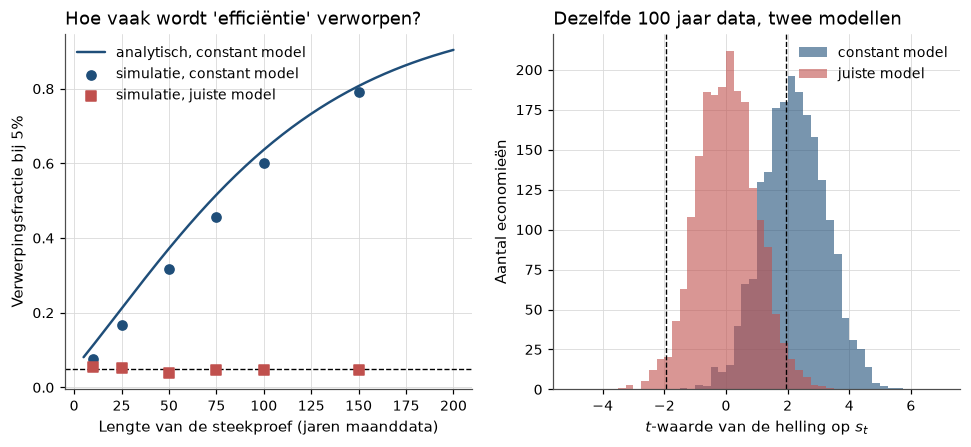

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

grid = np.linspace(5, 200, 200)
drift = np.sqrt(12 * grid * r2_population / (1 - r2_population))
axes[0].plot(grid, stats.norm.sf(1.96 - drift) + stats.norm.cdf(-1.96 - drift),
             color=hap.plotting.COLORS[0], label="analytisch, constant model")
axes[0].scatter(power.index, power["verwerpt constant model"],
                color=hap.plotting.COLORS[0], zorder=3, label="simulatie, constant model")
axes[0].scatter(power.index, power["verwerpt juiste model"],
                color=hap.plotting.COLORS[1], marker="s", zorder=3,
                label="simulatie, juiste model")
axes[0].axhline(0.05, color="black", lw=0.9, ls="--")
axes[0].set_title("Hoe vaak wordt 'efficiëntie' verworpen?")
axes[0].set_xlabel("Lengte van de steekproef (jaren maanddata)")
axes[0].set_ylabel("Verwerpingsfractie bij 5%")
axes[0].legend()

bins = np.linspace(-5, 7, 49)
for i, (name, tvals) in enumerate(t_at_100.items()):
    axes[1].hist(tvals, bins=bins, alpha=0.6, color=hap.plotting.COLORS[i], label=name)
for c in (-1.96, 1.96):
    axes[1].axvline(c, color="black", lw=0.9, ls="--")
axes[1].set_title("Dezelfde 100 jaar data, twee modellen")
axes[1].set_xlabel("$t$-waarde van de helling op $s_t$")
axes[1].set_ylabel("Aantal economieën")
axes[1].legend()
plt.show()

:::{figure} #cel-efficiente-markten-power
:label: fig-efficiente-markten-power
:width: 95%

Links: hoe vaak een onderzoeker het constante model verwerpt in een
volledig rationele economie. Na een eeuw maanddata lukt dat in ongeveer zes van de
tien steekproeven. Wie het juiste model kent, verwerpt in ongeveer 5% van de
gevallen, het nominale significantieniveau. Rechts: bij dezelfde honderd jaar data
ligt de $t$-waarde onder het constante model naar rechts verschoven, onder het
juiste model rond nul. De data zijn gelijk; alleen het model verschilt.
:::

De figuur laat risico of vergissing zien in een wereld waarin het antwoord
bekend is. Na honderd jaar vindt de onderzoeker met het constante model in 60%
van de economieën inefficiëntie, terwijl er per constructie alleen risico wordt
beloond. De onderzoeker met het juiste model ziet in dezelfde data een fair game.
Hun meningsverschil gaat niet over de data, maar over $m_{t+1}$.

Waarom duurt het zo lang? Met een kleine $R^2$ is de verwachte $t$-waarde na $N$
maanden ongeveer $\sqrt{N R^2}$, dezelfde rekensom als in [](#eq-bachelier-power).
Voor een verwachte $t$ van 1,96 zijn dus

```{math}
:label: eq-efficiente-markten-steekproef
N^{*} \approx \frac{1{,}96^{2}}{R^{2}} \approx \frac{3{,}84}{0{,}0044} \approx 870
\text{ maanden}
```

nodig, ruim tweeënzeventig jaar. In woorden: de benodigde steekproef is
omgekeerd evenredig met de voorspelbare fractie van de variantie. Bij $N^*$ is de
toets gemiddeld net significant, wat ongeveer de helft kans op verwerping geeft.
Voor 80% kans is $(1{,}96 + 0{,}84)^2/R^2 \approx 1780$ maanden nodig, bijna
honderdvijftig jaar. Hier is 0,84 het 80%-kwantiel van de standaardnormale verdeling.

Dit is de standaardfout van 2% uit [](#00-01-rendementen): bij 20% volatiliteit
is een gemiddeld jaarrendement na een eeuw maar op 2 procentpunt nauwkeurig. Hier
geldt dat voor een gemiddelde dat in de tijd beweegt. Een schommeling van 3,6 procentpunt per jaar
in het verwachte rendement is economisch groot en statistisch bijna onzichtbaar.

De simulatie ligt enkele procentpunten onder de formule. Een persistente $s_t$
spreidt in een eindige steekproef minder rond haar steekproefgemiddelde dan in de
populatie, en bevat dus minder informatie. Het verschil is het grootst rond 75
jaar, zes punten, en krimpt tot minder dan twee bij 150 jaar. De simulatie heeft
daardoor ongeveer tachtig jaar nodig voor een halve kans op verwerping.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Eugene F. Fama en Marshall E. Blume, *Filter Rules and Stock-Market
Trading*, Journal of Business 1966 {cite}`FamaBlume1966`. De regel zelf komt van
Sidney Alexander {cite}`Alexander1961`.

**Wat.** Tabel 3: het gemiddelde jaarrendement van filters van 0,5% tot 20% op de
dertig Dow Jones-aandelen, voor en na commissies, eind 1957 tot september 1962,
tegen buy-and-hold.

**Data hier.** De dagelijkse Amerikaanse marktportefeuille van Kenneth French en,
als verhandelbaar instrument, de ETF SPY vanaf 1993, beide via `hap.data`.

**Verschil met het origineel.** Fama en Blume gebruikten dertig aandelen, wij de
index. Naast hun volledige commissies rekenen wij met hun alternatief van 0,1% per
transactie, de clearingkosten die ook een handelaar op de beursvloer betaalde.

**Verwachte afwijking.** Door niet-synchrone handel heeft een index sterkere
autocorrelatie dan de aandelen erin (hun voetnoot 3), dus de niveaus wijken af.
Criteria voor het 0,5%-filter: (1) een voorsprong van de orde
$252\,(\rho_1\sigma_d\sqrt{2/\pi} - \mu)$, ver boven hun 1,7 procentpunt; (2) een
voorsprong die over deelperiodes met $\rho_1$ stijgt; (3) geen voorsprong op SPY.
```

We repliceren niet de voorspelregressie uit de simulatie maar het filter, omdat
het filter de joint hypothesis bijna omzeilt. De regel van Alexander, in de vorm van
Fama en Blume: stijgt de slotkoers
$\delta$ procent boven een eerder dal, ga lang. Daalt hij $\delta$ procent onder een eerdere
top, verkoop en ga short. We rekenen met de totaalrendementsindex, zodat de lange
positie dividend ontvangt en de korte het betaalt. Rendementen zijn gemiddelde log-rendementen
maal 252. De tabel zet onze index naast hun gepubliceerde waarden.

In [7]:
def filter_positions(level, x):
    """Alexander filter as in Fama-Blume: +1 long, -1 short, 0 before the first signal."""
    level = np.asarray(level, float)
    positions = np.zeros(len(level))
    state, start, peak, trough = 0, level[0], level[0], level[0]
    for t, p in enumerate(level):
        if state == 0:
            if p >= start * (1 + x):
                state, peak = 1, p
            elif p <= start * (1 - x):
                state, trough = -1, p
        elif state == 1:
            peak = max(peak, p)
            if p <= peak * (1 - x):
                state, trough = -1, p
        else:
            trough = min(trough, p)
            if p >= trough * (1 + x):
                state, peak = 1, p
        positions[t] = state
    return positions


def filter_performance(returns, x, cost=0.001, periods=252):
    """Annualised log return of an x-filter, before and after a cost per transaction."""
    held = pd.Series(filter_positions((1 + returns).cumprod(), x), index=returns.index)
    held = held.shift(1).fillna(0.0)                   # position at close t earns t+1
    first = held.ne(0).idxmax()                        # date of the first signal
    held, r = held.loc[first:], returns.loc[first:]
    gross = np.log1p(held * r)
    switches = held.diff().fillna(0.0).ne(0)
    return {
        "filter": x,
        "voor kosten": periods * gross.mean(),
        "na 0,1% per transactie": periods * (gross - cost * switches).mean(),
        "buy-and-hold": periods * np.log1p(r).mean(),
        "transacties per jaar": switches.sum() / (len(r) / periods),
    }


market = hap_data.market_daily()["Mkt"]
filters = (0.005, 0.01, 0.015, 0.02, 0.03, 0.05, 0.10, 0.20)
fama_blume_window = market.loc["1957-12":"1962-09-26"]
ours = pd.DataFrame([filter_performance(fama_blume_window, x) for x in filters]).set_index("filter")

published = pd.DataFrame(
    {
        "origineel: voor commissies": [0.1152, 0.0547, 0.0277, 0.0023, -0.0169, -0.0188, 0.0298, 0.0428],
        "origineel: na volle commissies (niet vergelijkbaar)": [-1.0359, -0.7494, -0.5614, -0.4515, -0.3049, -0.1662, -0.0143, 0.0298],
    },
    index=pd.Index(filters, name="filter"),
)
pd.concat([ours.add_prefix("hier: "), published], axis=1).round(4)

,hier: voor kosten,"hier: na 0,1% per transactie",hier: buy-and-hold,hier: transacties per jaar,origineel: voor commissies,origineel: na volle commissies (niet vergelijkbaar)
filter,,,,,,
0.005,0.2291,0.1813,0.1005,47.8218,0.1152,-1.0359
0.010,0.1872,0.1630,0.1053,24.1987,0.0547,-0.7494
0.015,0.1256,0.1089,0.1053,16.6887,0.0277,-0.5614
0.020,0.1344,0.1227,0.1078,11.7209,0.0023,-0.4515
0.030,0.1014,0.0934,0.1115,7.9601,-0.0169,-0.3049
0.050,0.1279,0.1252,0.0988,2.7048,-0.0188,-0.1662
0.100,0.0905,0.0896,0.0908,0.9265,0.0298,-0.0143
0.200,0.0595,0.0593,0.0739,0.2423,0.0428,0.0298


De kolom buy-and-hold verschilt per filter, omdat elk filter pas telt vanaf zijn
eerste signaal. Hun kolom na volle commissies is niet vergelijkbaar met onze 0,1%.
De cel rekent de voorspelde voorsprong van criterium 1 uit voor het venster.

In [8]:
def predicted_lead(returns, periods=252):
    """Annual lead over buy-and-hold of following yesterday's sign: rho_1 * sigma * sqrt(2/pi) - mu."""
    r = np.log1p(returns)
    return periods * (r.autocorr(1) * r.std() * np.sqrt(2 / np.pi) - r.mean())


window_log = np.log1p(fama_blume_window)
pd.Series({
    "eerste autocorrelatie": window_log.autocorr(1),
    "dagvolatiliteit": window_log.std(),
    "voorspelde voorsprong per jaar": predicted_lead(fama_blume_window),
    "gemeten voorsprong, 0,5%-filter voor kosten": ours.loc[0.005, "voor kosten"] - ours.loc[0.005, "buy-and-hold"],
}).round(4)

eerste autocorrelatie                          0.1752
dagvolatiliteit                                0.0068
voorspelde voorsprong per jaar                 0.1392
gemeten voorsprong, 0,5%-filter voor kosten    0.1286
dtype: float64

**Geslaagd** op criterium 1. Het 0,5%-filter verslaat buy-and-hold voor kosten met
12,9 procentpunt per jaar, tegen voorspeld 13,9 en tegen 1,7 bij Fama en Blume. Na
0,1% per transactie blijft ruim acht over.

Gedeeld met Fama en Blume is alleen dat het kleinste filter het meest verdient.
Bij hen is de voorsprong vanaf 1% weg, op de index wordt ze vanaf 3% grillig. Kosten
beslissen, omdat kleine filters vaak handelen: 48 keer per jaar op de index, 84
keer per aandeel bij Fama en Blume. Bij volle commissies, concludeerden zij,
verdiende vooral de makelaar. Let in de figuur op de afstand tussen de ronde
punten en de vierkanten bij de kleinste filters.

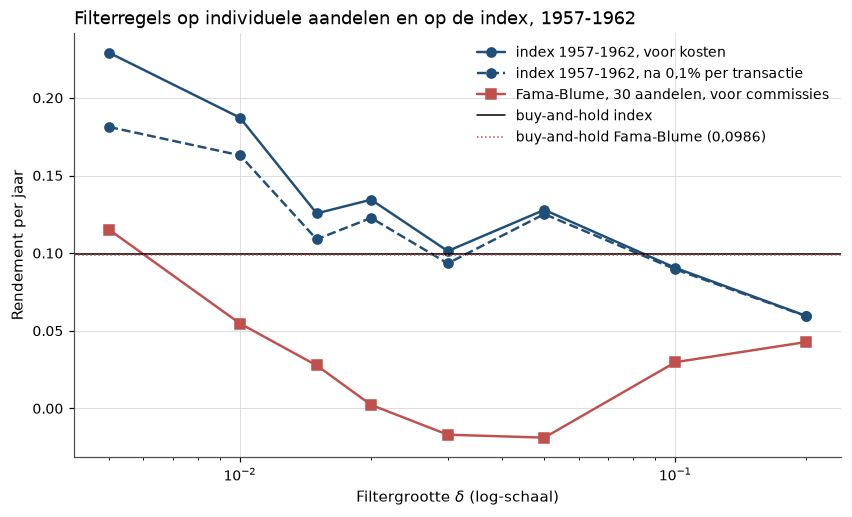

In [9]:
fig, ax = plt.subplots()
ax.plot(ours.index, ours["voor kosten"], "o-", color=hap.plotting.COLORS[0],
        label="index 1957-1962, voor kosten")
ax.plot(ours.index, ours["na 0,1% per transactie"], "o--", color=hap.plotting.COLORS[0],
        label="index 1957-1962, na 0,1% per transactie")
ax.plot(published.index, published["origineel: voor commissies"], "s-", color=hap.plotting.COLORS[1],
        label="Fama-Blume, 30 aandelen, voor commissies")
ax.axhline(252 * np.log1p(fama_blume_window).mean(), color="black", lw=1.0, label="buy-and-hold index")
ax.axhline(0.0986, color=hap.plotting.COLORS[1], lw=1.0, ls=":",
           label="buy-and-hold Fama-Blume (0,0986)")
ax.set_xscale("log")
ax.set_title("Filterregels op individuele aandelen en op de index, 1957-1962")
ax.set_xlabel("Filtergrootte $\\delta$ (log-schaal)")
ax.set_ylabel("Rendement per jaar")
ax.legend()
plt.show()

:::{figure} #cel-efficiente-markten-filters
:label: fig-efficiente-markten-filters
:width: 90%

Filterregels in het venster van Fama en Blume. De vierkanten zijn hun
gepubliceerde gemiddelden over dertig aandelen (tabel 3, kolom 1), de ronde punten
dezelfde regel op de marktindex. Beide zijn het hoogst bij het kleinste filter.
Boven 1% ligt de reeks van Fama en Blume ver onder buy-and-hold. Het verschil bij de kleinste filters is de extra autocorrelatie van
de index door niet-synchrone handel. Die zit in de meting, niet in iets wat te
kopen was.
:::

Fama en Blume schreven die extra autocorrelatie, naar Lawrence Fisher, toe aan
niet-synchrone handel. Criteria 2 en 3 toetsen dat: we herhalen het 0,5%-filter in vier
deelperiodes en op SPY, met de eerste autocorrelatie van de dagrendementen
ernaast.

In [10]:
periods_daily = {
    "1926-07 t/m 1956": market.loc[:"1956"],
    "1957-12 t/m 1962-09 (FB)": fama_blume_window,
    "1963 t/m 1989": market.loc["1963":"1989"],
    "1990 t/m 2026": market.loc["1990":],
}
spy = hap_data.yahoo(["SPY", "TLT", "GLD", "QQQ", "IWM"], "1993-01-01")["SPY"]  # shared cached download; only SPY is used
spy_returns = (spy / spy.shift(1) - 1).dropna()
periods_daily["French, zelfde dagen als SPY"] = market.loc[spy_returns.index[0]:spy_returns.index[-1]]
periods_daily["SPY 1993 t/m 2026 (verhandelbaar)"] = spy_returns

rows = {}
for name, r in periods_daily.items():
    perf = filter_performance(r, 0.005)
    rows[name] = {
        "eerste autocorrelatie dagrendement": np.log1p(r).autocorr(1),
        "0,5%-filter voor kosten": perf["voor kosten"],
        "na 0,1% per transactie": perf["na 0,1% per transactie"],
        "buy-and-hold": perf["buy-and-hold"],
        "voorsprong voor kosten": perf["voor kosten"] - perf["buy-and-hold"],
    }
subperiods = pd.DataFrame(rows).T
subperiods.round(4)

,eerste autocorrelatie dagrendement,"0,5%-filter voor kosten","na 0,1% per transactie",buy-and-hold,voorsprong voor kosten
1926-07 t/m 1956,0.0811,0.1353,0.0734,0.0759,0.0594
1957-12 t/m 1962-09 (FB),0.1752,0.2291,0.1813,0.1005,0.1286
1963 t/m 1989,0.2017,0.3109,0.2607,0.1031,0.2078
1990 t/m 2026,-0.0578,-0.0084,-0.0777,0.1041,-0.1125
"French, zelfde dagen als SPY",-0.0659,-0.0236,-0.0937,0.1033,-0.1269
SPY 1993 t/m 2026 (verhandelbaar),-0.0804,-0.0605,-0.1327,0.1027,-0.1632


**Geslaagd** op criteria 2 en 3. In de tabel stijgt de voorsprong van het filter
met de eerste autocorrelatie, en na 1990, bij een negatieve autocorrelatie, wordt
ze een verlies. Op de verhandelbare SPY verliest het filter het meest, nog voor
kosten. Ook een moderne index is dus iets trager dan een fonds dat werkelijk wordt
verhandeld.

```{admonition} Replicatie
:class: seealso

**Bron.** Michael C. Jensen, *The Performance of Mutual Funds in the Period
1945–1964*, Journal of Finance 1968 {cite}`Jensen1968`.

**Wat.** Tabellen 2 en 4: de alpha in
$R^{e}_{j,t+1} = \alpha_j + \beta_{j,M} R^{e}_{M,t+1} + u_{j,t+1}$ voor 115
fondsen, op jaardata; Jensen schrijft $R_{jt} - R_{Ft}$ voor het excess
rendement.

**Data hier.** Maandrendementen van zeven grote actieve Amerikaanse
aandelenfondsen en het indexfonds VFINX als controle, 1982–2026, via
`hap.data.yahoo`; markt en rente van French.

**Verschil met het origineel.** Jensen nam alle fondsen met tien jaar data. Wij
nemen zeven fondsen die vandaag groot en bekend zijn: overlevers, met de bias uit
[](#02-05-crsp-tape) in het voordeel van de fondsen.

**Verwachte afwijking.** Het indexfonds moet een alpha hebben van ongeveer min
zijn kosten, met $|t| < 2$. Voor de actieve fondsen verwachten wij, ondanks de
overlevingsbias, geen $t$ boven 2 en een gemiddelde alpha binnen één procentpunt
van nul.
```

De cel schat per fonds de alpha, de bèta en de $t$-waarde met
heteroskedasticiteitsrobuuste standaardfouten, op maanddata.

In [11]:
fund_names = {
    "FMAGX": "Fidelity Magellan", "AGTHX": "Growth Fund of America",
    "FCNTX": "Fidelity Contrafund", "PRGFX": "T. Rowe Price Growth Stock",
    "VWNDX": "Vanguard Windsor", "DODGX": "Dodge & Cox Stock",
    "TWCUX": "American Century Ultra", "VFINX": "Vanguard 500 Index (controle)",
}
fund_prices = hap_data.yahoo(list(fund_names), "1980-01-01").resample("ME").last()
fund_returns = (fund_prices / fund_prices.shift(1) - 1).loc["1982":]
factors = hap_data.market_monthly()

rows = {}
for ticker, name in fund_names.items():
    y = (fund_returns[ticker] - factors["RF"].reindex(fund_returns.index)).dropna()
    X = factors["Mkt-RF"].reindex(y.index)
    fit = hap.stats.newey_west(y, X, lags=0)
    rows[name] = {
        "alpha per jaar": 12 * fit.params.iloc[0],
        "t(alpha)": fit.tvalues.iloc[0],
        "bèta": fit.params.iloc[1],
        "maanden": int(fit.nobs),
    }
jensen = pd.DataFrame(rows).T
active = jensen.drop(index="Vanguard 500 Index (controle)")
jensen.loc["gemiddelde actieve fondsen"] = active.mean()
jensen.round(3)

,alpha per jaar,t(alpha),bèta,maanden
Fidelity Magellan,-0.006,-0.698,1.063,535.0
Growth Fund of America,-0.006,-0.645,0.998,535.0
Fidelity Contrafund,0.014,1.285,0.929,535.0
T. Rowe Price Growth Stock,-0.022,-2.277,1.006,535.0
Vanguard Windsor,-0.006,-0.523,0.920,535.0
Dodge & Cox Stock,0.011,0.889,0.937,535.0
American Century Ultra,-0.006,-0.420,1.211,535.0
Vanguard 500 Index (controle),-0.003,-0.708,0.967,535.0
gemiddelde actieve fondsen,-0.003,-0.341,1.009,535.0


De regressie is het CAPM: het verwachte excess rendement van een fonds is
evenredig met zijn bèta op de markt. De alpha meet dan wat een beheerder daarboven
verdient, een toets van de sterke vorm uit de tabel van Fama. Het indexfonds heeft een alpha van $-0{,}3\%$ per jaar met $t = -0{,}7$: kosten
plus het kleine verschil tussen de S&P 500 en de totale markt. De tabel hieronder
zet de actieve fondsen naast de getallen van Jensen.

In [12]:
jensen_1968 = {"aantal fondsen": 115, "gemiddelde alpha per jaar": -0.011,
               "gemiddelde bèta": 0.840, "fondsen met t(alpha) < -2": 14}
here = {"aantal fondsen": len(active), "gemiddelde alpha per jaar": active["alpha per jaar"].mean(),
        "gemiddelde bèta": active["bèta"].mean(),
        "fondsen met t(alpha) < -2": (active["t(alpha)"] < -2).sum()}
pd.DataFrame({"origineel": jensen_1968, "hier": here}).round(3)

,origineel,hier
aantal fondsen,115.000,7.000
gemiddelde alpha per jaar,-0.011,-0.003
gemiddelde bèta,0.840,1.009
fondsen met t(alpha) < -2,14.000,1.000


**Geslaagd.** Geen van de zeven actieve fondsen haalt een $t$ boven 2, en hun
gemiddelde alpha, $-0{,}3\%$ per jaar, ligt binnen één procentpunt van nul. De hoogste alpha, 1,4% voor
Fidelity Contrafund, is niet significant, en T. Rowe Price Growth Stock blijft
significant achter. Onze bèta's liggen rond 1,01, die van Jensen rond 0,84,
waarschijnlijk omdat zijn fondsen meer kas aanhielden.

De standaardfout van een alpha is na 44 jaar maanddata nog ongeveer één
procentpunt per jaar: voor Contrafund 1,4% gedeeld door $t = 1{,}3$. Een beheerder
die werkelijk één procent per jaar toevoegt, is na een loopbaan niet van geluk te
onderscheiden. Dat is de standaardfout van 2% uit [](#00-01-rendementen) bij de
sterke vorm.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Veel, met één kleine aanname: concurrentie om
informatie maakt voorspelbare winst na kosten onmogelijk. Daaruit volgen de
bijna-nulautocorrelaties van [](#01-02-bachelier). Het verklaart waarom
filterregels falen zodra dividenden en kosten meetellen: op de verhandelbare SPY
verloor het filter al voor kosten. En het verklaart waarom fondsen de markt niet
verslaan, van Jensens $-1{,}1\%$ tot gemiddeld $-0{,}3\%$ voor onze zeven actieve
overlevers. De praktische les, dat een goedkoop
indexfonds moeilijk te verslaan is, werd een industrie.

**Waar het breekt.** Op een eigenschap die we hebben bewezen: elk patroon van
voorspelbaarheid heeft een SDF die het rationeel maakt
({prf:ref}`thm-efficiente-markten-elke-sdf`). Efficiëntie zonder model verbiedt
dus bijna niets. Het meetbare feit: op de index verdiende het 0,5%-filter tussen
1957 en 1962 bijna 13 procentpunt per jaar meer dan buy-and-hold, en na
clearingkosten nog ruim acht. Efficiëntie alleen zegt niet of dat een
inefficiëntie is of een meetfout.

Bovendien vraagt een rationele schommeling in het verwachte rendement zeventig
(formule) tot tachtig jaar (simulatie) data voor een halve kans op detectie.

**Risico of vergissing?** De Chicago-lezing van het filterfeit: het is een
meetfout door niet-synchrone handel, die verdwijnt bij een verhandelbaar
instrument. Voor zover rendementen wel voorspelbaar zijn, is dat een
wisselende prijs van risico, zoals na slecht nieuws in het toy-voorbeeld.

De Yale-lezing: niet alleen de gemeten slotkoers, ook de werkelijke prijs van
weinig verhandelde aandelen past zich traag aan. Dan was er echte winst te halen,
en waren kosten de *limits of arbitrage* (grenzen aan wat arbitrageurs kunnen
wegwerken, omdat handelen geld en risico kost) die de vergissing tot na 1990 lieten
bestaan. Op de index is het filterfeit dus een meetfout. Of er in de jaren zestig
daarnaast iets verhandelbaars was, blijft open. Scheiden kan met data over wie wanneer tegen welke prijs kon handelen, en
met een onafhankelijk gemeten $m_{t+1}$. Het eerste ontbreekt voor de jaren
zestig, het tweede nog altijd.

**Wat er daarna kwam.** Na de koersgeschiedenis kwam het publieke nieuws: hoe
snel verwerkt een prijs een aandelensplitsing of een winstcijfer? Daarvoor
ontwikkelden Fama, Fisher, Jensen en Roll in 1969 de event study
{cite}`FamaFisherJensenRoll1969`: zie [](#02-07-event-studies).

## Oefeningen

:::{exercise}
:label: ex-efficiente-markten-1

**Instap: hoeveel SDF-schommeling kost voorspelbaarheid?** Neem het
toy-voorbeeld met $m = 1 - k$ als het meezit en $m = 1 + k$ als het tegenzit, in
beide perioden.

1. Toon aan dat $p_1(\text{slecht}) = 80 - 20k$. Bepaal $k$ zodat het verwachte
   rendement na slecht nieuws 10% is. Hoe groot is het dan na goed nieuws?
2. Voor welke $k$ ontstaat arbitrage, en wat is dan het hoogste verwachte
   rendement na slecht nieuws dat deze economie rationeel kan hebben?
:::

:::{solution} ex-efficiente-markten-1
:class: dropdown

**(1)** $p_1(\text{slecht}) = \tfrac12(1-k)100 + \tfrac12(1+k)60 = 80 - 20k$, en
evenzo $p_1(\text{goed}) = 120 - 20k$. De risicocorrectie is in beide gevallen
$20k$, omdat de spreiding in beide 40 is. Uit $80/(80 - 20k) = 1{,}10$ volgt
$k = 4/11 \approx 0{,}364$.

In [13]:
k = 4 / 11
pd.Series(toy_economy((1 - k, 1 + k))).round(4)

prijs op t=1, goed nieuws              112.7273
prijs op t=1, slecht nieuws             72.7273
prijs op t=0                            85.4545
verwachte prijs op t=1                  92.7273
verwacht rendement t=0 naar 1            0.0851
verwacht rendement na goed nieuws        0.0645
verwacht rendement na slecht nieuws      0.1000
verwachte prijs op t=1 onder q          85.4545
dtype: float64

Na goed nieuws is het verwachte rendement 6,45%, op $t = 0$ 8,51%. De SDF heeft
dan een standaarddeviatie van 36% per periode: $\SD(m)/\E(m) = k$, de verhouding
uit {prf:ref}`thm-efficiente-markten-elke-sdf`.

**(2)** Bij $k \ge 1$ is $m \le 0$ als het meezit. Een claim die alleen dan
uitbetaalt, kost dan niets, en dat is arbitrage. Voor $k \uparrow 1$ gaat
$p_1(\text{slecht})$ naar 60 en het verwachte rendement na slecht nieuws naar
$80/60 - 1 = 33\%$. Wat dit leert: de joint hypothesis staat elk patroon toe,
maar alleen zonder arbitrage, en hoe sterker het patroon, hoe volatieler en minder
geloofwaardig de SDF die het moet verklaren.
:::

:::{exercise}
:label: ex-efficiente-markten-2

**Afleiding: het Samuelson-effect.** Laat de spotprijs een AR(1) rond $\bar S$
volgen: $S_{t+1} - \bar S = \phi(S_t - \bar S) + \nu_{t+1}$, met
$0 < \phi < 1$ en $\Var(\nu) = \sigma_S^2$.

1. Leid $F_t = \E_t[S_T]$ af en toon aan dat
   $\Var(F_{t+1} - F_t) = \phi^{2(T-t-1)}\sigma_S^2$.
2. Bereken voor $\phi = 0{,}5$ en $T = 12$ de verhouding tussen de variantie van
   de termijnprijsverandering in de laatste en in de eerste periode, en controleer
   die met de simulatie uit de theorie.
:::

:::{solution} ex-efficiente-markten-2
:class: dropdown

**(1)** Herhaald substitueren geeft
$S_T - \bar S = \phi^{T-t}(S_t - \bar S) + \sum_{j=1}^{T-t}\phi^{T-t-j}\nu_{t+j}$,
dus $F_t = \bar S + \phi^{T-t}(S_t - \bar S)$ en
$F_{t+1} - F_t = \phi^{T-t-1}\left[(S_{t+1} - \bar S) - \phi(S_t - \bar S)\right]
= \phi^{T-t-1}\nu_{t+1}$. Omdat $\nu_{t+1}$ onafhankelijk is van
$\mathcal{F}_t$, is $\Var(F_{t+1} - F_t) = \phi^{2(T-t-1)}\sigma_S^2$. Het
gemiddelde $\bar S$ valt weg: het zit al in de prijs.

**(2)** De verhouding is $\phi^{-22} = 2^{22}$. De cel vergelijkt dat met de
paden uit de theoriesectie.

In [14]:
changes = np.diff(futures, axis=1)
pd.Series({
    "Var laatste / Var eerste, theorie": phi ** (-2 * (horizon - 1)),
    "Var laatste / Var eerste, simulatie": changes[:, -1].var() / changes[:, 0].var(),
}).round(0)

Var laatste / Var eerste, theorie      4194304.0
Var laatste / Var eerste, simulatie    4208815.0
dtype: float64

De theorie geeft ongeveer 4,2 miljoen, en de simulatie wijkt enkele promille af.
Wat dit
leert: de stelling van Samuelson zegt niet alleen dat termijnprijzen
onvoorspelbaar zijn, maar voorspelt ook toetsbaar hoe hun onzekerheid in de tijd
verloopt.
:::

:::{exercise}
:label: ex-efficiente-markten-3

**Uitbreiding van de replicatie: break-even kosten.**

1. Bereken voor het 0,5%-filter op de index de break-even kosten $c^{*}$ per
   transactie, waarbij het filter na kosten evenveel oplevert als buy-and-hold,
   voor 1957–1962, 1963–1989 en 1990–2026.
2. Herhaal met een filter dat alleen lang gaat en anders de risicovrije rente van
   French verdient.
3. Was dit filter ooit door een belegger te incasseren?
:::

:::{solution} ex-efficiente-markten-3
:class: dropdown

Kosten zijn lineair in het aantal transacties, dus
$c^{*} = (\text{voor kosten} - \text{buy-and-hold}) / \text{transacties per jaar}$.

In [15]:
def long_only_performance(returns, rf, x, periods=252):
    """Long when the filter says long, otherwise earn the risk-free rate."""
    held = pd.Series(filter_positions((1 + returns).cumprod(), x), index=returns.index)
    held = held.shift(1).fillna(0.0)
    first = held.ne(0).idxmax()
    long = held.loc[first:].eq(1).astype(float)
    r, f = returns.loc[first:], rf.reindex(returns.index).loc[first:]
    switches = long.diff().fillna(0.0).ne(0).sum() / (len(r) / periods)
    return periods * np.log1p(long * r + (1 - long) * f).mean(), switches


rf_daily = hap_data.market_daily()["RF"]
rows = {}
for name in ["1957-12 t/m 1962-09 (FB)", "1963 t/m 1989", "1990 t/m 2026"]:
    r = periods_daily[name]
    perf = filter_performance(r, 0.005)
    long_return, long_switches = long_only_performance(r, rf_daily, 0.005)
    rows[name] = {
        "c* lang/short": (perf["voor kosten"] - perf["buy-and-hold"]) / perf["transacties per jaar"],
        "c* alleen lang": (long_return - perf["buy-and-hold"]) / long_switches,
        "lang/short voor kosten": perf["voor kosten"],
        "alleen lang voor kosten": long_return,
        "buy-and-hold": perf["buy-and-hold"],
    }
pd.DataFrame(rows).T.round(4)

,c* lang/short,c* alleen lang,lang/short voor kosten,alleen lang voor kosten,buy-and-hold
1957-12 t/m 1962-09 (FB),0.0027,0.0016,0.2291,0.1773,0.1005
1963 t/m 1989,0.0041,0.0027,0.3109,0.2398,0.1031
1990 t/m 2026,-0.0016,-0.0005,-0.0084,0.0675,0.1041


Tot 1990 ligt de break-even tussen 0,27% en 0,41% per transactie: boven de 0,1%
van een handelaar op de beursvloer, onder de commissie van een gewone belegger.
Na 1990 is $c^{*}$ negatief, want het filter verliest al voor kosten. Alleen lang
gaan geeft een lagere $c^{*}$, 0,16% en 0,27% voor 1990, en na 1990 blijft ook die
variant met 6,8% onder de 10,4% van buy-and-hold.

**(3)** Toen de kosten hoog waren, bestond de trend alleen in een index die niet te
kopen was. Toen die index te koop was, bestond de trend niet meer. Wat dit
leert: "na alle kosten" in de definitie van Jensen is geen voetnoot, maar de helft
van het argument.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->